In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
X = df.drop(columns=['Survived'])
y= df['Survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_test.shape,X_train.shape

((179, 3), (712, 3))

In [10]:
X_train.isnull().mean()*100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [11]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [12]:
X_train['Age_Median'] = X_train['Age'].fillna(median_age)
X_train['Age_Mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_Median'] = X_train['Fare'].fillna(median_age)
X_train['Fare_Mean'] = X_train['Fare'].fillna(mean_age)

In [14]:
X_train.sample(4)

,Age,Fare,Family,Age_Median,Age_Mean,Fare_Median,Fare_Mean
527,NaN,221.7792,0,28.75,29.785904,221.7792,221.7792
690,31.0,57.0000,1,31.00,31.000000,57.0000,57.0000
645,48.0,76.7292,1,48.00,48.000000,76.7292,76.7292
489,9.0,15.9000,2,9.00,9.000000,15.9000,15.9000


In [16]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_Median'].var())
print('Age Variance after mean imputation: ', X_train['Age_Mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_Median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_Mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2324.9576136149317
Fare Variance after mean imputation:  2324.623996772905


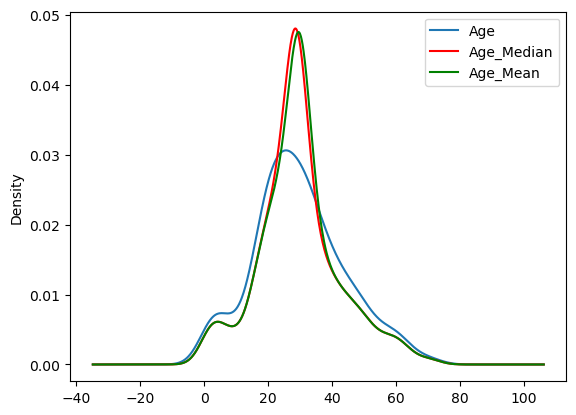

In [17]:
fig = plt.figure()
ax= fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax)

X_train['Age_Median'].plot(kind='kde',ax=ax,color='red')

X_train['Age_Mean'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

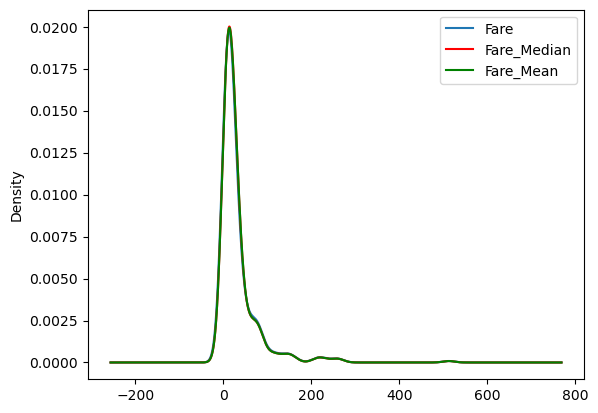

In [18]:
fig = plt.figure()
ax= fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)

X_train['Fare_Median'].plot(kind='kde',ax=ax,color='red')

X_train['Fare_Mean'].plot(kind='kde',ax=ax,color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [19]:
X_train.cov()

,Age,Fare,Family,Age_Median,Age_Mean,Fare_Median,Fare_Mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.280487,66.383530
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.404484,16.399278
Age_Median,204.349513,57.957599,-5.112563,161.989566,161.812625,54.710043,54.793876
Age_Mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.483705,52.565299
Fare_Median,66.280487,2448.197914,16.404484,54.710043,52.483705,2324.957614,2324.765012
Fare_Mean,66.383530,2448.197914,16.399278,54.793876,52.565299,2324.765012,2324.623997


In [20]:
X_train.corr()

,Age,Fare,Family,Age_Median,Age_Mean,Fare_Median,Fare_Mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.089604,0.089754
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205710,0.205660
Age_Median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.089149,0.089292
Age_Mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.085568,0.085707
Fare_Median,0.089604,1.000000,0.205710,0.089149,0.085568,1.000000,0.999989
Fare_Mean,0.089754,1.000000,0.205660,0.089292,0.085707,0.999989,1.000000


<Axes: >

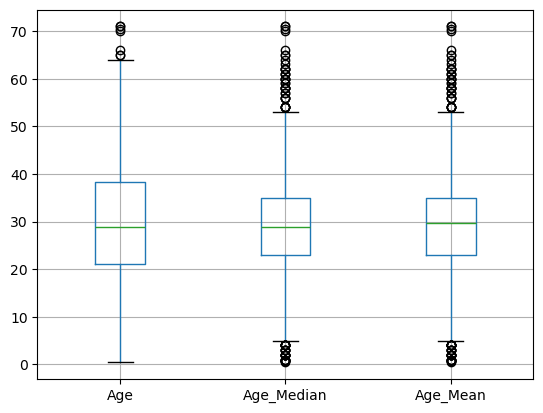

In [21]:
X_train[['Age','Age_Median','Age_Mean']].boxplot()

<Axes: >

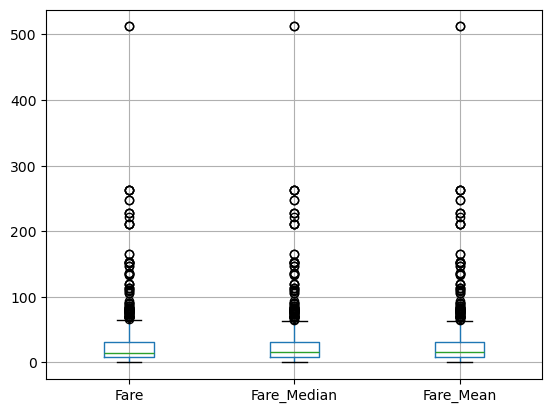

In [22]:
X_train[['Fare','Fare_Median','Fare_Mean']].boxplot()

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [45]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [46]:
trf= ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [47]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [48]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [49]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [50]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))